Using backend: tensorflow.compat.v1



Instructions for updating:
non-resource variables are not supported in the long term



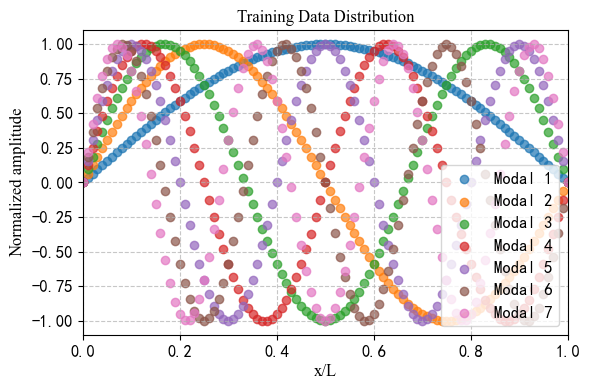

Epoch 1000, Loss: 0.1683
Epoch 2000, Loss: 0.1157
Epoch 3000, Loss: 0.0878
Epoch 4000, Loss: 0.0257
Epoch 5000, Loss: 0.0121
Epoch 6000, Loss: 0.0102
Epoch 7000, Loss: 0.0086
Epoch 8000, Loss: 0.0064
Epoch 9000, Loss: 0.0113
Epoch 10000, Loss: 0.0068
Epoch 11000, Loss: 0.0126
Epoch 12000, Loss: 0.0080
Epoch 13000, Loss: 0.0099
Epoch 14000, Loss: 0.0060
Epoch 15000, Loss: 0.0067
Epoch 16000, Loss: 0.0065
Epoch 17000, Loss: 0.0049
Epoch 18000, Loss: 0.0063
Epoch 19000, Loss: 0.0087
Epoch 20000, Loss: 0.0055
Epoch 21000, Loss: 0.0094
Epoch 22000, Loss: 0.0057
Epoch 23000, Loss: 0.0068
Epoch 24000, Loss: 0.0061
Epoch 25000, Loss: 0.0088
Epoch 26000, Loss: 0.0103
Epoch 27000, Loss: 0.0060
Epoch 28000, Loss: 0.0046
Epoch 29000, Loss: 0.0071
Epoch 30000, Loss: 0.0061
Epoch 31000, Loss: 0.0056
Epoch 32000, Loss: 0.0092
Epoch 33000, Loss: 0.0044
Epoch 34000, Loss: 0.0062
Epoch 35000, Loss: 0.0065
Epoch 36000, Loss: 0.0042
Epoch 37000, Loss: 0.0074
Epoch 38000, Loss: 0.0078
Epoch 39000, Loss: 0.

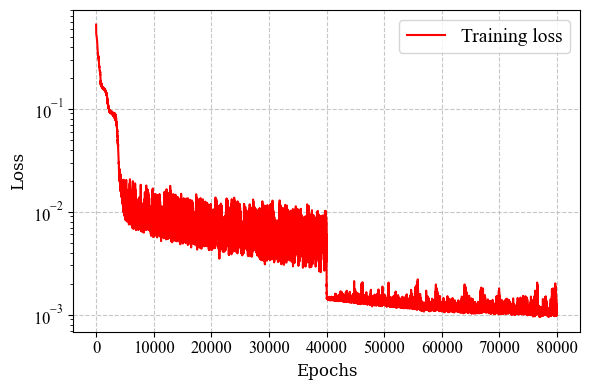

C:\Users\15984\anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\engine\training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


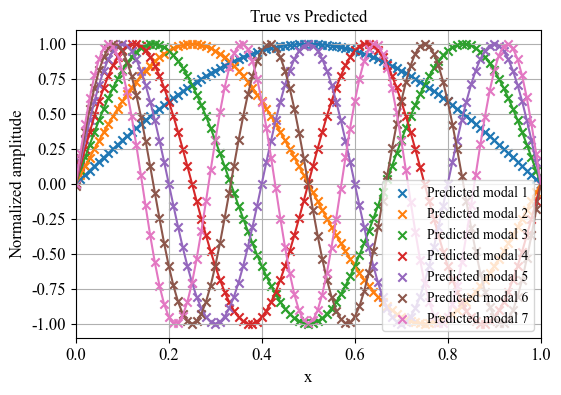

In [1]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import savefig
from sympy import integrate, exp, sin, log, oo, pi,symbols
import deepxde as dde
import scipy.io as scio
from mpl_toolkits.mplot3d import Axes3D
from deepxde.backend import tf
import datetime
import os
from pylab import mpl
from scipy.signal import chirp, spectrogram
mpl.rcParams['font.sans-serif']=['SimHei']
mpl.rcParams['axes.unicode_minus']=False
from matplotlib.pyplot import MultipleLocator
import re
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from math import sqrt, pi

from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.layers import Activation
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import LambdaCallback

import pandas as pd


def sin_activation(x):
    return tf.math.sin(x)


get_custom_objects().update({'sin': Activation(sin_activation)})

data_pre = np.loadtxt('Modal.txt')  
X_pre = data_pre[:, 0].reshape(-1, 1)  
y_pre = data_pre[:, 1:8]             

y_pre = y_pre / np.max(y_pre, axis=0)

font = {'family': 'Times New Roman', 'color': 'black', 'weight': 'normal', 'size': 12}


plt.figure(figsize=(6,4))
for i in range(y_pre.shape[1]):
    plt.scatter(X_pre, y_pre[:, i], label=f'Modal {i+1}', alpha=0.7)

plt.title("Training Data Distribution",fontdict=font)
plt.xlabel("x/L",fontdict=font)
plt.ylabel("Normalized amplitude",fontdict=font)
plt.xlim([0,1])
plt.legend(loc='lower right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  
plt.savefig('modal_train data.png', dpi=300)  
plt.show()


def create_model():
    model = Sequential()
    model.add(Dense(64, input_dim=1, activation='sin'))  
    model.add(Dense(128, activation='sin')) 
    model.add(Dense(64, activation='sin')) 
    model.add(Dense(7))  
    return model

# Define the learning rate scheduler function
def scheduler(epoch, lr):
    if epoch <40000:
        return 0.001  # First 40000 epochs
    else:
        return 0.0001 # Next

# Create the LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(scheduler)

tf.compat.v1.disable_eager_execution()

pre_model = create_model()

history1 = pre_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mae',  
    metrics=['accuracy']
)


def on_epoch_end(epoch, logs):
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}, Loss: {logs['loss']:.4f}")

print_callback = LambdaCallback(on_epoch_end=on_epoch_end)
history1 = pre_model.fit(
    X_pre, y_pre,
    epochs= 80000, 
    batch_size=512,  
    callbacks=[print_callback, lr_scheduler],  
    verbose=0  # 静默模式
)


#for layer in model.layers[:3]:
for layer in pre_model.layers:
    layer.trainable = False


plt.figure(figsize=(6, 4))
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(history1.history['loss'], label='Training loss', color='red', linestyle='-')
plt.yscale('log')

plt.title('', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12})
plt.xlabel('Epochs', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12})
plt.ylabel('Loss', fontdict={'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12})

plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('modal_train.png', dpi=300)
plt.show()
    

y_train_pred = pre_model.predict(X_pre)
plt.figure(figsize=(6,4))
plt.rcParams['font.family'] = 'Times New Roman'
for i in range(y_pre.shape[1]):
    plt.plot(X_pre, y_pre[:, i], label='', alpha=1)  
    plt.scatter(X_pre, y_train_pred[:, i], label=f'Predicted modal {i+1}', alpha=1, marker='x')  
plt.title("True vs Predicted", fontdict=font)
plt.xlabel("x", fontdict=font)
plt.ylabel("Normalized amplitude", fontdict=font)
plt.xlim(0, 1)
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12) 
plt.legend(loc='lower right', fontsize=10)  
plt.grid(True)
plt.savefig('modal_pre.png', dpi=300)  
plt.show()

Shape of y_star (6 series, N_times): (7, 3000)
Shape of X_star (6 locations): (7,)
(3000,) (7, 3000)
(7, 1) (3000, 1)
(7, 3000)
Filtered t shape: (300,)
Filtered y shape: (7, 300)
(7, 300) (7, 300)


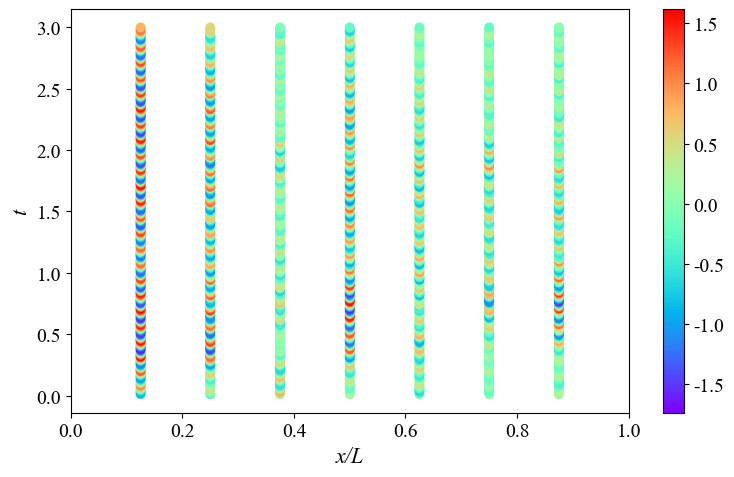

(2100, 2)
(2100, 1)


C:\Users\15984\anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\optimizer_v2\gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)
C:\Users\15984\anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\optimizer_v2\adamax.py:90: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adamax, self).__init__(name, **kwargs)


xt shape: (None, 2)
ei shape after lstm and dense: (None, 7)
output shape before return: (None, 1)


C:\Users\15984\anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\engine\training_v1.py:2057: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


Epoch 1000, Loss: 0.3786665, Validation Loss: 0.3785868
Epoch 2000, Loss: 0.2797434, Validation Loss: 0.2779374
Epoch 3000, Loss: 0.2286091, Validation Loss: 0.2293992
Epoch 4000, Loss: 0.2048284, Validation Loss: 0.1996023
Epoch 5000, Loss: 0.1494301, Validation Loss: 0.1536242
Epoch 6000, Loss: 0.1226099, Validation Loss: 0.1217886
Epoch 7000, Loss: 0.1039480, Validation Loss: 0.1037005
Epoch 8000, Loss: 0.0863870, Validation Loss: 0.0870683
Epoch 9000, Loss: 0.0818263, Validation Loss: 0.0796137
Epoch 10000, Loss: 0.0764408, Validation Loss: 0.0875747
Epoch 11000, Loss: 0.0579539, Validation Loss: 0.0552299
Epoch 12000, Loss: 0.0585905, Validation Loss: 0.0722565
Epoch 13000, Loss: 0.0304776, Validation Loss: 0.0280097
Epoch 14000, Loss: 0.0086703, Validation Loss: 0.0087960
Epoch 15000, Loss: 0.0195991, Validation Loss: 0.0207911
Epoch 16000, Loss: 0.0160019, Validation Loss: 0.0072358
Epoch 17000, Loss: 0.0315341, Validation Loss: 0.0297665
Epoch 18000, Loss: 0.0046824, Validation

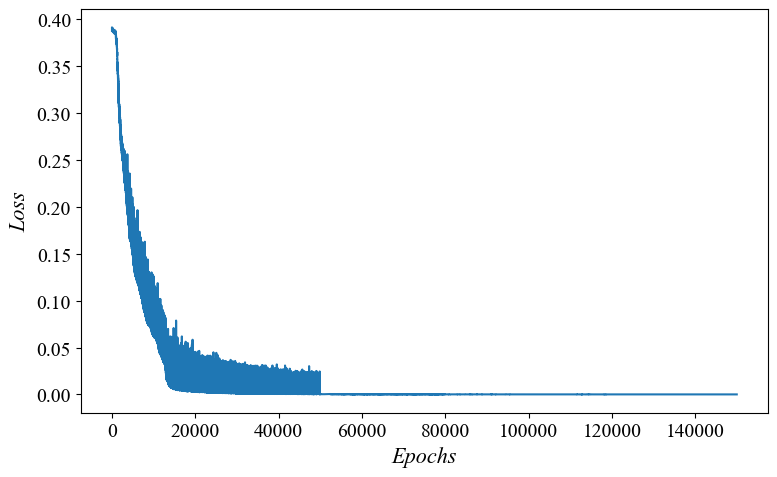

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data_w = pd.read_csv('Pipe_Displacement_result.txt', sep='\s+', header=None, encoding='utf-8')



t_star = data_w.iloc[:, 0].to_numpy()-33  # 转换为 numpy 数组


selected_indices = np.array([21, 41, 61, 81, 101, 121, 141])
y_star = data_w.iloc[:, selected_indices].to_numpy().T
print(f"Shape of y_star (6 series, N_times): {y_star.shape}")


X_star = np.array([1/8, 2/8, 3/8, 4/8, 5/8, 6/8, 7/8])
print(f"Shape of X_star (6 locations): {X_star.shape}")

print(t_star.shape,  y_star.shape)

x = X_star.reshape(-1, 1)  # (n, 1)
t = t_star.reshape(-1, 1)  # (m, 1)

print(x.shape,t.shape)

y = y_star
print(y.shape)


t = t.flatten()  
t_mask = (t >= 0) & (t <=3)


t_filtered = t[t_mask]  
y_filtered = y[:, t_mask]   

print(f"Filtered t shape: {t_filtered.shape}")
print(f"Filtered y shape: {y_filtered.shape}")

X, T = np.meshgrid(x, t_filtered, indexing='ij')  
print(X.shape, T.shape)

plt.rcParams['font.size'] = 14 

plt.figure(figsize=(8, 5))
plt.scatter(X, T, c=y_filtered, cmap='rainbow')  
plt.colorbar()  


font = {'style': 'italic', 'size': 16}  

plt.xlabel('x/L', fontdict=font)  
plt.ylabel('t', fontdict=font)  
plt.xlim(0, 1)  
plt.tight_layout()
plt.savefig('training_data.jpg', dpi=1200, format='jpg')
plt.show()


x_train = X.flatten()[:, None]
t_train = T.flatten()[:, None]
y_train = y_filtered .flatten()[:, None]  # (n*m, 1)

inputs = np.hstack([x_train,t_train])  # (n*m, 2)
outputs = y_train
print(inputs.shape)
print(outputs.shape)


initializer1 = tf.random_normal_initializer(mean=0.0, stddev=0.05)
initializer2 = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)
initializer3 = tf.keras.initializers.VarianceScaling()
initializer4 = tf.keras.initializers.GlorotNormal()
initializer5 = tf.keras.initializers.GlorotUniform()
initializer6 = tf.keras.initializers.LecunNormal()
initializer7 = tf.keras.initializers.LecunUniform()
# initializer = initializer4
initializer = initializer2

activation_func1 = tf.keras.layers.LeakyReLU(alpha=0.01)
activation_func2 = tf.nn.sigmoid
activation_func3 = tf.nn.relu
activation_func4 =tf.nn.swish
activation_func5 = tf.nn.elu


def sine_activation(x):
    return tf.sin(x)
def custom_activation(x):
    return tf.nn.relu(x) + tf.nn.sigmoid(x) + tf.nn.tanh(x) + x
activation_func =activation_func1


class CustomMultiLSTMModel(tf.keras.Model):
    def __init__(self):
        super(CustomMultiLSTMModel, self).__init__()
        self.lstm_layers = tf.keras.Sequential([
            tf.keras.layers.LSTM(256, return_sequences=True, input_shape=(None, 1)),  
            tf.keras.layers.LSTM(256, return_sequences=True),
            tf.keras.layers.LSTM(256, return_sequences=True), 
            tf.keras.layers.LSTM(256, return_sequences=False),  
        ])
      
        self.dense_layers = tf.keras.Sequential([
             tf.keras.layers.Dense(7)  # 输出为 10 维向量
        ])
        
        self.pi = tf.constant(np.pi, dtype=tf.float32)

    def call(self, xt):
        print(f"xt shape: {xt.shape}")
        x = tf.ensure_shape(xt[:, 0:1], [None, 1])  
        t = tf.ensure_shape(xt[:, 1:2], [None, 1]) 

        t_expanded = tf.expand_dims(t, axis=-1)  
        lstm_output= self.lstm_layers(t_expanded) 
        ei = self.dense_layers(lstm_output)  
        print(f"ei shape after lstm and dense: {ei.shape}")

        output = tf.zeros_like(x)  
        for i in range(1, 8):
            ei_term = tf.expand_dims(ei[:, (i - 1)], axis=1)  
            output += ei_term * tf.sin(i * self.pi * x)  
        output = tf.ensure_shape(output, [None, 1])  
        print(f"output shape before return: {output.shape}")
        return output

model = CustomMultiLSTMModel()
optimizerQ = tf.keras.optimizers.Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999, epsilon=1e-8)
optimizer2 = tf.keras.optimizers.SGD(lr=0.001, momentum=0.0, decay=0.0, nesterov=False)
optimizer= tf.keras.optimizers.Adamax(lr=0.0005, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
optimizer4 = tf.keras.optimizers.Adagrad(learning_rate=0.01)
optimizer5 = tf.keras.optimizers.Adadelta(learning_rate=1.0)
optimizer6 = tf.keras.optimizers.Nadam(learning_rate=0.0001)
optimizer7 = tf.keras.optimizers.Ftrl(learning_rate=0.01)

model.compile(optimizer=optimizer,loss='mse', metrics=['mae'])

class PrintLossCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 1000 == 0:  
            print(f"Epoch {epoch+1}, Loss: {logs['loss']:.7f}, Validation Loss: {logs['val_loss']:.7f}")

def lr_scheduler(epoch, lr):
    if epoch < 50000:
        return 0.01 
    elif epoch < 80000:
        return 0.001 
    elif epoch < 120000:
        return 0.0005  
    else:
        return 0.0001 


lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)
dataset = tf.data.Dataset.from_tensor_slices((inputs, outputs))
dataset = dataset.batch(50000).prefetch(buffer_size=tf.data.AUTOTUNE)


history = model.fit(
    dataset,  
    epochs=150000,
    validation_data=dataset,  
    callbacks=[lr_callback, PrintLossCallback()],
    verbose=0
)

plt.figure(figsize=(6, 4))
# 使用不同的线型和颜色
plt.plot(history.history['loss'], label='Data Loss', color='blue', linestyle='-', linewidth=2)  # 虚线
#plt.plot(epochs, physics_losses, label='Physics Loss', color='blue', linestyle='-.')  # 点划线
#plt.plot(epochs, total_losses, label='Total Loss', color='red', linestyle='-')  # 点线
plt.yscale('log')  # 将 Y 轴设置为对数坐标
plt.title('', fontdict=font)
plt.xlabel('Epochs', fontdict=font)
plt.ylabel('Loss', fontdict=font)

plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("损失函数.png", dpi=300)
plt.show()

y_pred shape: (48300, 1)
y_filtered shape: (7, 300)


C:\Users\15984\AppData\Local\Temp\ipykernel_21524\2403037421.py:41: RuntimeWarning: invalid value encountered in divide
  R_y_error = abs((y_predP-yP_filtered)/yP_filtered)


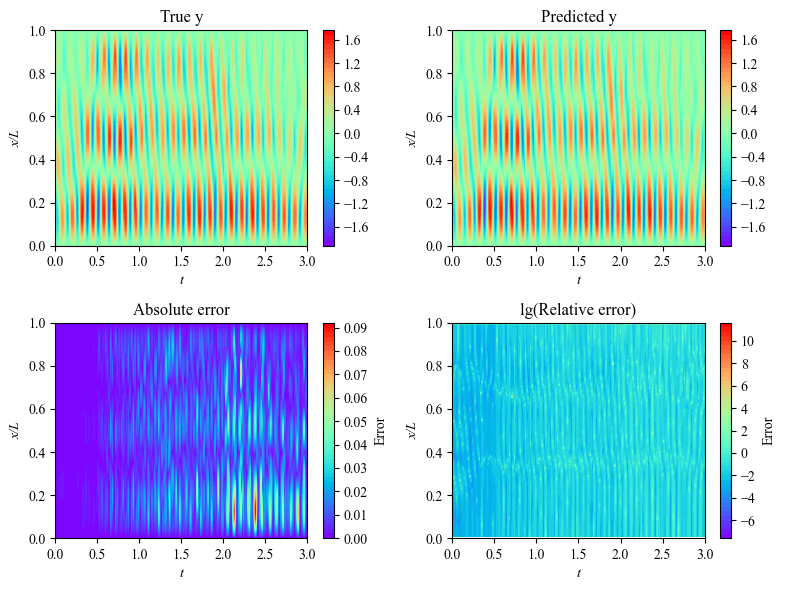

In [10]:
data_wp = pd.read_csv('Pipe_Displacement_result.txt', sep='\s+', header=None, encoding='utf-8')
t_starP = data_wp.iloc[:, 0].to_numpy()-33  #2700 转换为 numpy 数组
y_starP = data_wp.iloc[:, 1:].to_numpy().T  #161 2700

X_starP = np.arange(0, 1+1/160, 1/160)

xP = X_starP.reshape(-1, 1)  # (n, 1)
tP = t_starP.reshape(-1, 1)  # (m, 1)
yP = y_starP

tP = tP.flatten()  
tP_mask = (tP >= 0) & (tP <=3)


tP_filtered = tP[tP_mask] 
yP_filtered = yP[:, tP_mask]  

XP, TP = np.meshgrid(xP, tP_filtered, indexing='ij')  

x_P = XP.flatten()[:, None]
t_P = TP.flatten()[:, None]

inputsP = np.hstack([x_P,t_P])  # (n*m, 2)

y_pred = model.predict(inputsP)

print(f"y_pred shape: {y_pred.shape}")
print(f"y_filtered shape: {y_filtered.shape}")

y_predP= y_pred.reshape(yP_filtered.shape)

ERROR=np.abs(y_predP-yP_filtered)


R_y_error = abs((y_predP-yP_filtered)/yP_filtered)

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10  


plt.figure(figsize=(8, 6))
plt.subplot(2, 2, 1)
plt.contourf(tP_filtered.flatten(), xP.flatten(), yP_filtered, levels=50, cmap='rainbow')
font = {'style': 'italic', 'size': 10}  
plt.colorbar()
plt.xlim(0, 3)  
plt.ylim(0, 1) 
plt.xlabel('t',fontdict=font)
plt.ylabel('x/L', fontdict=font)
plt.title('True y')



plt.subplot(2, 2, 2)
plt.contourf(tP_filtered.flatten(), xP.flatten(), y_predP, levels=50, cmap='rainbow')
plt.colorbar()
plt.xlim(0, 3)  
plt.ylim(0, 1)  
plt.xlabel('t',fontdict=font)
plt.ylabel('x/L',fontdict=font)
plt.title('Predicted y')


plt.subplot(2, 2, 3)
plt.contourf(tP_filtered.flatten(), xP.flatten(), ERROR, levels=50, cmap='rainbow')
plt.colorbar(label='Error')
plt.xlim(0, 3)  # 确保 x 轴从 0 开始
plt.ylim(0, 1)  # 根据 xP 的范围调整 y 轴
plt.xlabel('t',fontdict=font)
plt.ylabel('x/L',fontdict=font)
plt.title('Absolute error')
log_R_y_error = np.log10(R_y_error) 
plt.subplot(2, 2, 4)
plt.contourf(tP_filtered.flatten(), xP.flatten(), log_R_y_error , levels=50, cmap='rainbow')
plt.colorbar(label='Error')
plt.xlim(0, 3)  # 确保 x 轴从 0 开始
plt.ylim(0, 1)  # 根据 xP 的范围调整 y 轴
plt.xlabel('t',fontdict=font)
plt.ylabel('x/L',fontdict=font)
plt.title('lg(Relative error)')



# 调整子图布局
plt.tight_layout()

plt.savefig('SM-CF pre.jpg', dpi=1200,format='jpg')  # 设置分辨率为300d
plt.show()

In [9]:
optimizer= tf.keras.optimizers.Adamax(lr=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
# 使用Dataset加载数据训练
history = model.fit(
    dataset,  # 使用Dataset代替numpy数据
    epochs=60000,
    validation_data=dataset,  # 同样使用Dataset加载验证数据
    callbacks=[PrintLossCallback()],
    verbose=0
)

C:\Users\15984\anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\optimizer_v2\adamax.py:90: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adamax, self).__init__(name, **kwargs)
C:\Users\15984\anaconda3\envs\tensorflow-gpu\lib\site-packages\keras\engine\training_v1.py:2057: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


Epoch 1000, Loss: 0.0000, Validation Loss: 0.0000153
Epoch 2000, Loss: 0.0000, Validation Loss: 0.0000152
Epoch 3000, Loss: 0.0000, Validation Loss: 0.0000157
Epoch 4000, Loss: 0.0000, Validation Loss: 0.0000160
Epoch 5000, Loss: 0.0000, Validation Loss: 0.0000161
Epoch 6000, Loss: 0.0000, Validation Loss: 0.0000151
Epoch 7000, Loss: 0.0000, Validation Loss: 0.0000152
Epoch 8000, Loss: 0.0000, Validation Loss: 0.0000150
Epoch 9000, Loss: 0.0000, Validation Loss: 0.0000159
Epoch 10000, Loss: 0.0000, Validation Loss: 0.0000162
Epoch 11000, Loss: 0.0000, Validation Loss: 0.0000149
Epoch 12000, Loss: 0.0000, Validation Loss: 0.0000155
Epoch 13000, Loss: 0.0000, Validation Loss: 0.0000151
Epoch 14000, Loss: 0.0000, Validation Loss: 0.0000151
Epoch 15000, Loss: 0.0000, Validation Loss: 0.0000151
Epoch 16000, Loss: 0.0000, Validation Loss: 0.0000163
Epoch 17000, Loss: 0.0000, Validation Loss: 0.0000152
Epoch 18000, Loss: 0.0000, Validation Loss: 0.0000163
Epoch 19000, Loss: 0.0000, Validation

C:\Users\15984\AppData\Local\Temp\ipykernel_21524\401486087.py:26: RuntimeWarning: invalid value encountered in divide
  RR_error=abs((fft_magnitude_pred_positive-fft_magnitude_true_positive)/fft_magnitude_true_positive)


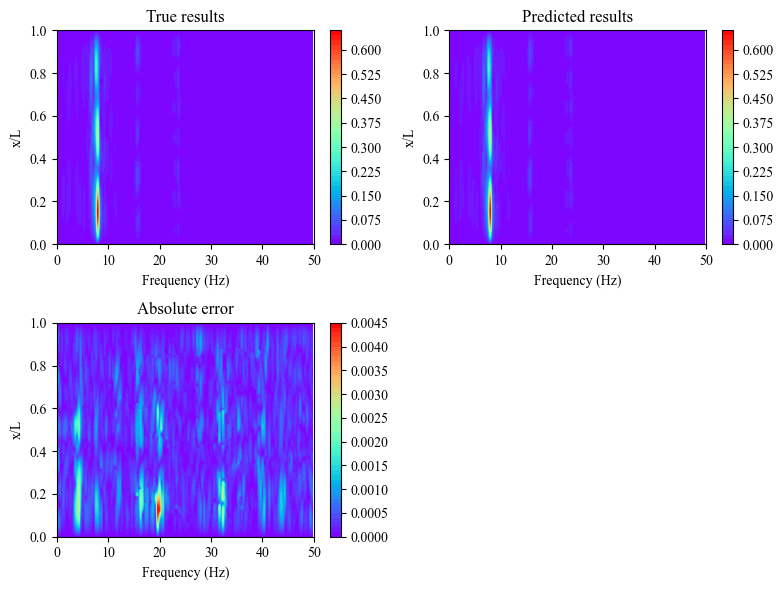

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 对 True y 和 Predicted y 进行 FFT
def compute_fft_magnitude(data, dt):
    fft_results = np.fft.fft(data, axis=1)  # 在时间轴 (axis=1) 上执行 FFT
    fft_magnitude = np.abs(fft_results) / data.shape[1]  # 幅值归一化
    freqs = np.fft.fftfreq(data.shape[1], d=dt)  # 计算频率轴
    return freqs, fft_magnitude

# 时间步长
dt = tP_filtered[1] - tP_filtered[0]

# 计算 True y 的 FFT
freqs, fft_magnitude_true = compute_fft_magnitude(yP_filtered, dt)
positive_freqs = freqs[freqs >= 0]
fft_magnitude_true_positive = fft_magnitude_true[:, freqs >= 0]

# 计算 Predicted y 的 FFT
_, fft_magnitude_pred = compute_fft_magnitude(y_predP, dt)
fft_magnitude_pred_positive = fft_magnitude_pred[:, freqs >= 0]



error=abs(fft_magnitude_pred_positive-fft_magnitude_true_positive)
RR_error=abs((fft_magnitude_pred_positive-fft_magnitude_true_positive)/fft_magnitude_true_positive)

# 绘制频率云图
plt.figure(figsize=(8, 6))

# True y 的频率云图
plt.subplot(2,2, 1)
plt.contourf(positive_freqs, xP.flatten(), fft_magnitude_true_positive, levels=50, cmap='rainbow')
plt.colorbar(label='')
plt.xlabel('Frequency (Hz)')
plt.ylabel('x/L')
plt.xlim(0, 50)  # 确保 x 轴从 0 开始
plt.title('True results')

# Predicted y 的频率云图
plt.subplot(2, 2, 2)
plt.contourf(positive_freqs, xP.flatten(), fft_magnitude_pred_positive, levels=50, cmap='rainbow')
plt.colorbar(label='')
plt.xlabel('Frequency (Hz)')
plt.ylabel('x/L')
plt.xlim(0, 50)  # 确保 x 轴从 0 开始
# 调整布局
plt.title('Predicted results')
# Predicted y 的频率云图
plt.subplot(2, 2, 3)
plt.contourf(positive_freqs, xP.flatten(), error, levels=50, cmap='rainbow')
plt.colorbar(label='')
plt.xlabel('Frequency (Hz)')
plt.ylabel('x/L')
plt.xlim(0, 50)  # 确保 x 轴从 0 开始
plt.title('Absolute error')

plt.tight_layout()
plt.savefig('SM-CF 频率.jpg', dpi=1200,format='jpg')  # 设置分辨率为300d
plt.show()


Pearson correlation coefficient: 0.9998244316385294
决定系数 (R²): 0.9996488941013084


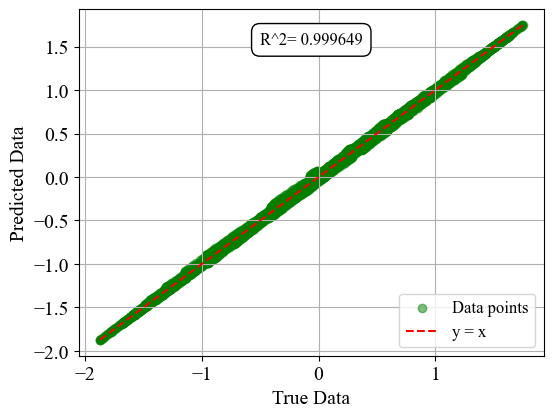

In [11]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # 设定字体大小为14

# 创建图形
plt.figure(figsize=(6, 4.5))

# 绘制真实值和预测值的散点图
plt.scatter(yP_filtered, y_predP, color="green", alpha=0.5, label="Data points")
y2_data = yP_filtered.flatten()
Y_PRE = y_predP.flatten()
# 计算皮尔逊相关系数
correlation, _ = pearsonr(y2_data,Y_PRE)
print(f"Pearson correlation coefficient: {correlation}")
r_squared = correlation ** 2
print(f"决定系数 (R²): {r_squared}")
# 在图中添加相关系数
plt.text(0.5, 0.9, f"R^2= {r_squared:.6f}", fontsize=12, ha='center', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# 绘制y = x线（完美预测的参考线）
plt.plot([min(y2_data), max(y2_data)], [min(y2_data), max(y2_data)], color="red", linestyle="--", label="y = x")

# 添加标签和图例
plt.xlabel("True Data")
plt.ylabel("Predicted Data")
plt.title("")
plt.xticks(fontsize=14)  # 设置x轴刻度字体大小
plt.yticks(fontsize=14)  # 设置y轴刻度字体大小
plt.legend(loc='lower right', fontsize=12)  #
plt.grid()

# 保存图像
plt.savefig("预测精度.png", dpi=300)

# 显

In [14]:
# *** 计算 RMSE 和 MAE ***
# 计算均方误差 (MSE)
mse = np.mean((yP_filtered-y_predP)**2)
# 计算均方根误差 (RMSE)
rmse = np.sqrt(mse)
# 计算平均绝对误差 (MAE)
mae = np.mean(np.abs(yP_filtered-y_predP))

print(f"\nRMSE (Root Mean Squared Error): {rmse:.10f}")
print(f"MAE (Mean Absolute Error): {mae:.10f}")


RMSE (Root Mean Squared Error): 0.0108758199
MAE (Mean Absolute Error): 0.0065493699
